In [ ]:
import os, sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import seaborn as sns

os.system(f'git clone https://github.com/m-j-r-q/Cura.git /kaggle/working/Cura')
sys.path.append('/kaggle/working/Cura/backend/src')

IMAGE_DIR  = '/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/images-224/images-224'
DATA_DIR   = '/kaggle/input/datasets/junaidrasul/cura-metadata'
OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Cloning into '/kaggle/working/Cura'...


Device: cuda


In [2]:
from dataset import CuraDataset, DISEASES, NUM_CLASSES
from transforms import val_transform
from model import build_model

test_df = pd.read_csv(f'{DATA_DIR}/test.csv')

test_loader = DataLoader(
    CuraDataset(test_df, IMAGE_DIR, val_transform),
    batch_size=16, shuffle=False, num_workers=0, pin_memory=False
)

print(f"Test images: {len(test_df)}")
print(f"Test batches: {len(test_loader)}")

Test images: 11196
Test batches: 700


In [3]:
def get_predictions(model, loader, device):
    model.eval()
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            images = images.to(device)
            probs  = torch.sigmoid(model(images))
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            
            if (i + 1) % 100 == 0:
                print(f"  Batch {i+1}/{len(loader)}")

    return (
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_probs,  axis=0)
    )

In [4]:
ARCHITECTURES = {
    'densenet121': 'densenet121_best.pt',
    'resnet50':    'resnet50_best.pt',
    'efficientnet_b0': 'efficientnet_b0_best.pt',
}

results = {}  # stores labels and probs per architecture

for arch, filename in ARCHITECTURES.items():
    print(f"\nEvaluating {arch}...")
    
    model = build_model(arch, pretrained=False).to(device)
    state_dict = torch.load(f'{DATA_DIR}/{filename}', map_location=device)
    model.load_state_dict(state_dict)
    
    labels, probs = get_predictions(model, test_loader, device)
    results[arch] = {'labels': labels, 'probs': probs}
    
    # Free GPU memory before next model
    del model
    torch.cuda.empty_cache()
    
    print(f"{arch} done.")


Evaluating densenet121...
  Batch 100/700
  Batch 200/700
  Batch 300/700
  Batch 400/700
  Batch 500/700
  Batch 600/700
  Batch 700/700
densenet121 done.

Evaluating resnet50...
  Batch 100/700
  Batch 200/700
  Batch 300/700
  Batch 400/700
  Batch 500/700
  Batch 600/700
  Batch 700/700
resnet50 done.

Evaluating efficientnet_b0...
  Batch 100/700
  Batch 200/700
  Batch 300/700
  Batch 400/700
  Batch 500/700
  Batch 600/700
  Batch 700/700
efficientnet_b0 done.


In [5]:
auc_data = {}

for arch in ARCHITECTURES:
    labels = results[arch]['labels']
    probs  = results[arch]['probs']
    
    aucs = []
    for i in range(NUM_CLASSES):
        if labels[:, i].sum() > 0:
            auc = roc_auc_score(labels[:, i], probs[:, i])
        else:
            auc = float('nan')
        aucs.append(auc)
    
    auc_data[arch] = aucs

auc_df = pd.DataFrame(auc_data, index=DISEASES)
auc_df['mean'] = auc_df.mean(axis=1)
auc_df.loc['MEAN'] = auc_df.mean()

print(auc_df.round(4).to_string())
auc_df.to_csv(f'{OUTPUT_DIR}/auc_results.csv')

                    densenet121  resnet50  efficientnet_b0    mean
Atelectasis              0.7978    0.7964           0.7948  0.7964
Cardiomegaly             0.9140    0.9091           0.8962  0.9064
Effusion                 0.8796    0.8788           0.8733  0.8772
Infiltration             0.7092    0.7099           0.7046  0.7079
Mass                     0.8357    0.8412           0.8177  0.8315
Nodule                   0.7355    0.7461           0.7425  0.7413
Pneumonia                0.7665    0.7558           0.7421  0.7548
Pleural_Thickening       0.7926    0.8024           0.8087  0.8012
Pneumothorax             0.8587    0.8676           0.8584  0.8616
Consolidation            0.7987    0.7957           0.7965  0.7970
Edema                    0.8887    0.8766           0.8757  0.8803
Emphysema                0.9263    0.9261           0.9004  0.9176
Fibrosis                 0.8200    0.7976           0.8154  0.8110
Hernia                   0.8808    0.8943           0.8797  0.

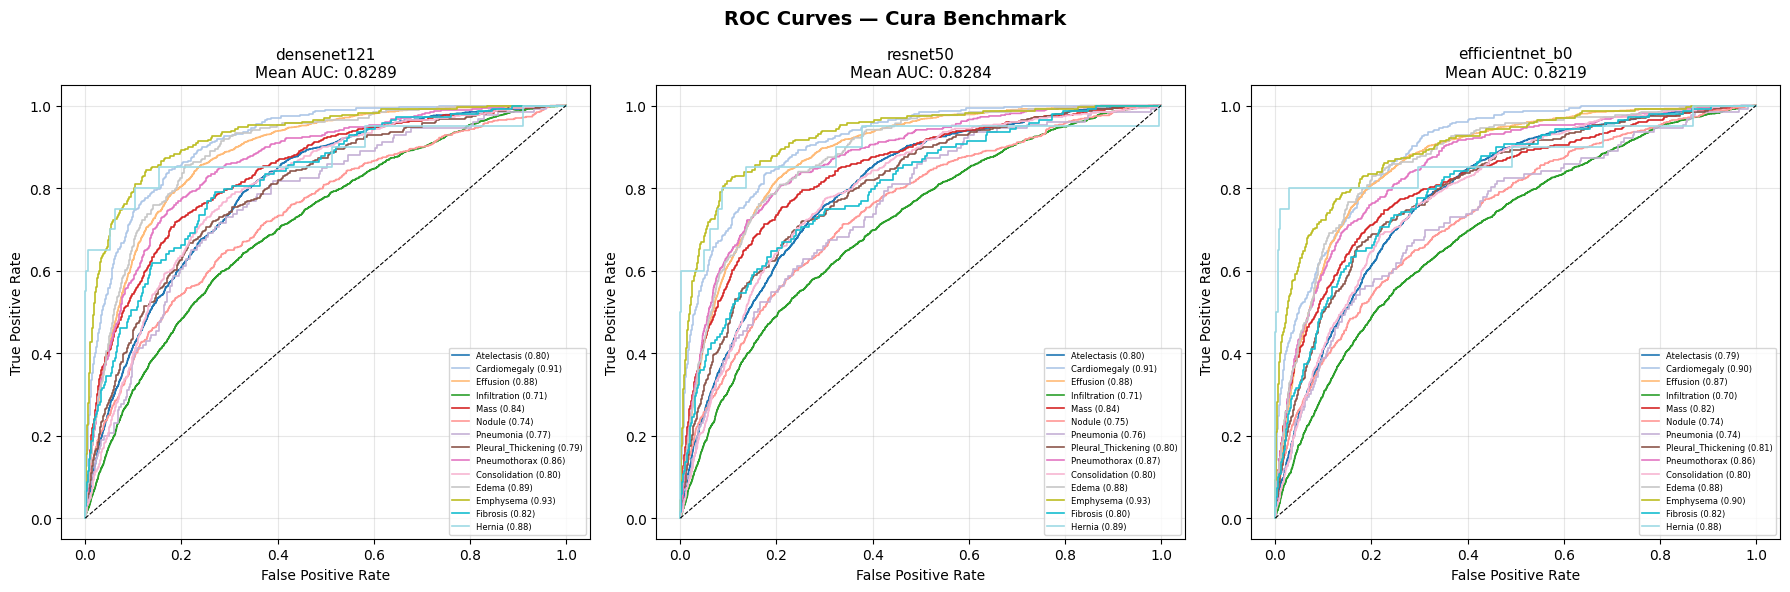

Saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))

for ax, arch in zip(axes, ARCHITECTURES):
    labels = results[arch]['labels']
    probs  = results[arch]['probs']
    
    for i, disease in enumerate(DISEASES):
        if labels[:, i].sum() > 0:
            fpr, tpr, _ = roc_curve(labels[:, i], probs[:, i])
            auc = roc_auc_score(labels[:, i], probs[:, i])
            ax.plot(fpr, tpr, color=colors[i], 
                   label=f'{disease} ({auc:.2f})', linewidth=1.2)
    
    ax.plot([0,1], [0,1], 'k--', linewidth=0.8)
    ax.set_title(f'{arch}\nMean AUC: {auc_df.loc["MEAN", arch]:.4f}', fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=6, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves — Cura Benchmark', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

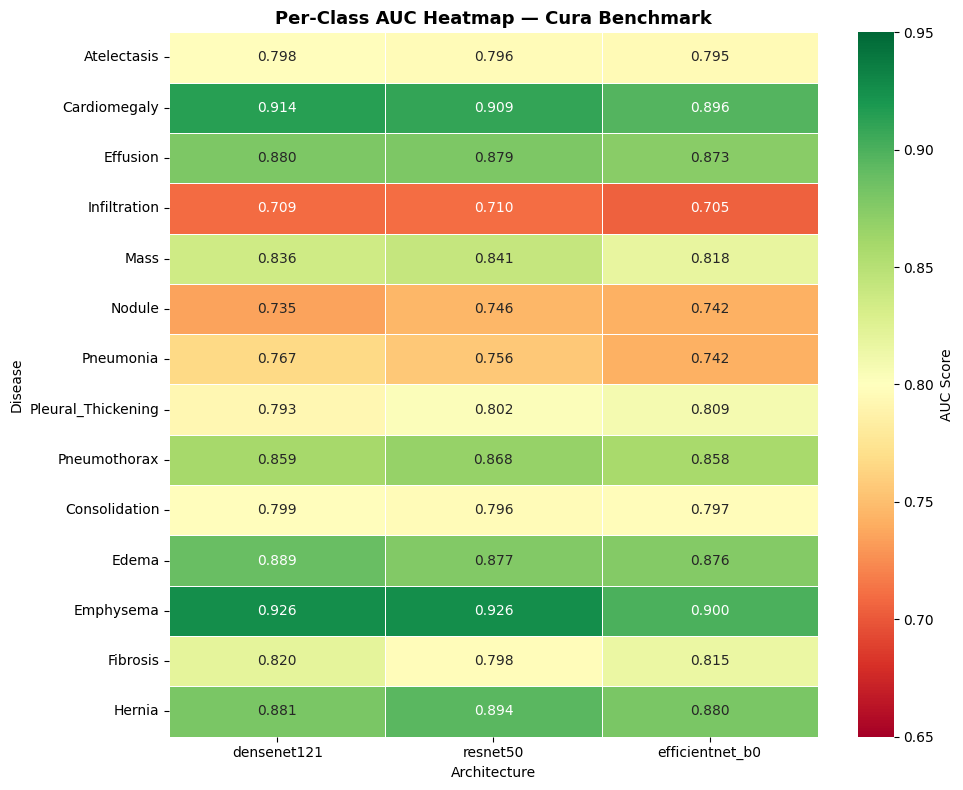

Saved.


In [7]:
plt.figure(figsize=(10, 8))

plot_df = auc_df.drop('mean', axis=1).drop('MEAN', axis=0)

sns.heatmap(
    plot_df,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0.65,
    vmax=0.95,
    linewidths=0.5,
    cbar_kws={'label': 'AUC Score'}
)

plt.title('Per-Class AUC Heatmap — Cura Benchmark', fontsize=13, fontweight='bold')
plt.xlabel('Architecture')
plt.ylabel('Disease')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")